In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import umap
import numpy as np

In [2]:
day24 = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/o8p_day24_s12_results.csv", index_col="label").drop(columns=["nucleus_percent_touching_1", "nucleus_bounds"])
day24 = day24[['foci_count'] + [col for col in day24.columns if col != 'foci_count']]
day24

,foci_count,nucleus_area,nucleus_i,nucleus_j,nucleus_intensity_mean,nucleus_intensity_max,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,foci_area,nucleus_number_neighbors_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors
label,,,,,,,,,,,,,,
1,10,1069.0,1626.681946,25270.460243,1917.960711,2737.0,1033.0,332.572849,0.711610,117,0,1838.055437,1991.112228,1.829429
2,1,1091.0,1836.065078,22567.976169,1080.065078,1759.0,379.0,249.204348,0.459015,2,0,1377.943193,1387.774393,69.997282
3,12,1279.0,2330.057076,15284.928851,2057.698984,3273.0,332.0,372.990217,0.664652,226,0,646.323985,1136.550260,5.235132
4,2,2064.0,2759.281008,23822.818314,1078.665698,2011.0,279.0,294.094888,0.654092,18,0,164.794390,247.537171,8.502625
5,12,1940.0,2788.794845,23577.046907,970.484536,1859.0,190.0,277.138514,0.655708,231,0,87.994696,247.537171,16.075205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5081,38,7540.0,39124.704775,18869.474668,197.401724,766.0,0.0,170.649570,0.830990,1758,0,131.103677,167.273222,17.469074
5082,7,3516.0,39305.602673,20307.226394,107.144767,296.0,0.0,58.527663,0.780247,233,0,441.903642,493.008795,117.155548
5083,19,4690.0,39664.264819,23492.662473,1568.605970,3280.0,107.0,869.739035,0.611145,498,0,3109.118868,3155.747503,0.009980


In [ ]:
# Compute correlation matrix
co_mtx = day24[day24["nucleus_intensity_mean"]>1000].corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

In [ ]:
# Compute correlation matrix
co_mtx = day24.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

In [ ]:
# Compute correlation matrix
co_mtx = ctrl_1gray.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

In [ ]:
# Compute correlation matrix
co_mtx = df_clean.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

In [ ]:
df_clean = df

In [7]:
day24["log_foci"] = np.log1p(day24["foci_count"].copy())


# df_clean["log_foci_area"] = np.log1p(df_clean["foci_area"])
# df_clean["log_second_neighbor_distance"] = np.log1p(df_clean["nucleus_second_neighbor_distance"])
# df_clean["log_first_neighbor_distance"] = np.log1p(df_clean["nucleus_first_neighbor_distance"])

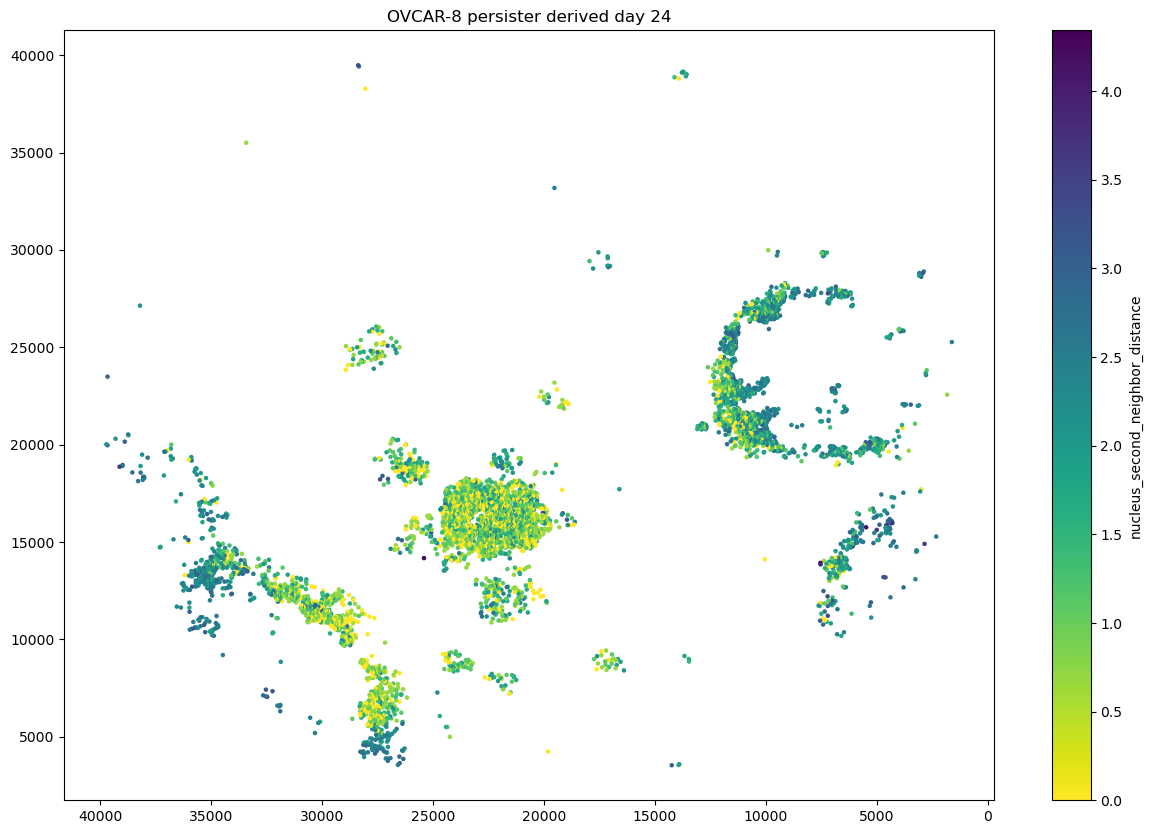

In [8]:
plt.figure(figsize=(15,10))

plt.scatter(
    day24["nucleus_i"],
    day24["nucleus_j"],
    c=day24["log_foci"],
    s=5,
    cmap="viridis_r"
)

plt.colorbar(label="nucleus_second_neighbor_distance")
plt.title("OVCAR-8 persister derived day 24")
plt.gca().invert_xaxis()
plt.show()

In [ ]:
# constants -- processing
umPerPx = 0.325
nucleiThreshold = 50
nucleiMin = 150/umPerPx**2
nucleiMax = 12000/umPerPx**2
nucleiMean = 300/umPerPx**2

In [ ]:
nucleiMin

In [ ]:
plt.hist(day24["nucleus_area"],bins=30)

In [ ]:
day24[(day24["nucleus_area"]<7000) & (day24["nucleus_area"]>500)]["nucleus_area"].describe()
# day24.sort_values(by="nucleus_area", ascending=True).head(n=20)

In [ ]:
day24_filtered = day24.sort_values(by="nucleus_area", ascending=True).head(n=20)

In [ ]:
plt.figure(figsize=(15,10))

plt.scatter(
    day24["nucleus_i"],
    day24["nucleus_j"],
    c=day24["log_foci"],
    s=5,
    cmap="viridis"
)

plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.colorbar(label="log_foci (count)")
#plt.gca().invert_yaxis()
plt.title("OVCAR-8 persister derived day 7")
plt.show()

In [ ]:

# Plotting correlation heatmap
dataplot = sns.heatmap(df.corr(numeric_only=True))

# Displaying heatmap
plt.show()

In [ ]:
scaled_statistics = StandardScaler().fit_transform(df)

type(scaled_statistics), scaled_statistics.shape

In [ ]:
fix = np.where(np.isnan(scaled_statistics), 0, scaled_statistics)

In [ ]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(fix)
type(embedding), embedding.shape

In [ ]:
sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    data = df,
                    hue='foci_area')

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

In [ ]:
num_classes = 2

kmeans = KMeans(n_clusters=num_classes, random_state=42).fit(embedding)

kmeans_prediction = kmeans.predict(embedding)

sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    hue=kmeans_prediction)

In [ ]:
sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    hue=kmeans_prediction)

In [ ]:
sns.scatterplot(data=df_clean, x="nucleus_number_neighbors_1", y="foci_count")
plt.show()

In [ ]:
sns.scatterplot(data=df_clean, x="log_second_neighbor_distance", y="foci_count")
plt.show()

In [ ]:
df["density_bin"] = pd.qcut(df["density_2"], 10)

sns.boxplot(
    data=df,
    x="density_bin",
    y="foci_count"
)

In [ ]:
df["crowding"] = 1 / (
    df["nucleus_first_neighbor_distance"] +
    df["nucleus_second_neighbor_distance"]
)

In [ ]:
data["nuclei_i"]

In [ ]:
df3 = pd.concat([df, data[["nuclei_i"] + ["nuclei_j"]]], axis=1, join="outer", sort=False).reset_index()

In [ ]:
df3

In [ ]:
df = df3

In [ ]:
coords = day24.drop_co

In [ ]:
from sklearn.neighbors import NearestNeighbors

#coords = day24[["nucleus_i","nucleus_j"]].values
coords = day24[["nuclei_i","nuclei_j"]]

nbrs = NearestNeighbors(n_neighbors=6).fit(coords)
distances, _ = nbrs.kneighbors(coords)

# rk = distances[:,5]

# df["density_k5"] = 5 / (np.pi * rk**2)

In [ ]:
distances

In [ ]:
df["density_k5"].describe()

In [ ]:
sns.histplot(df["density_k5"], bins=50)
plt.show()

In [ ]:
df["log_density_k5"] = np.log10(df["density_k5"])
df["log_foci"] = np.log1p(df["foci_count"])

In [ ]:
sns.scatterplot(
    data=df,
    x="density_k5",
    y="foci_count",
    alpha=0.3
)
plt.show()

In [ ]:
sns.scatterplot(
    data=df,
    x="log_density_k5",
    y="log_foci",
    alpha=0.3
)
plt.show()

In [ ]:
plt.figure(figsize=(15,10))

plt.scatter(
    df["nucleus_i"],
    df["nucleus_j"],
    c=df["log_foci"],
    s=5,
    cmap="viridis_r"
)
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.colorbar(label="log_foci")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
plt.figure(figsize=(20,18))

plt.scatter(
    df["nuclei_i"],
    df["nuclei_j"],
    c=df["log_density_k5"],
    s=5,
    cmap="viridis"
)

plt.colorbar(label="log_density_k5")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
plt.scatter(
    df["nuclei_i"],
    df["nuclei_j"],
    c=df["log_density_k5"],
    s=np.sqrt(df["foci_count"]+1)*3,
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="density")
plt.gca().invert_yaxis()

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = df.copy()

df["log_density_k5"] = np.log(df["density_k5"])
# safer if any zeros might exist:
# df["log_density_k5"] = np.log1p(df["density_k5"])

model = smf.glm(
    formula="foci_count ~ log_density_k5 + nucleus_area",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(model.summary())


In [ ]:
df["density_bin"] = pd.qcut(df["log_density_k5"], 10)

plt.figure(figsize=(8,4))

sns.pointplot(
    data=df,
    x="density_bin",
    y="foci_count",
    errorbar=("ci",95)
)

plt.xticks(rotation=45)
plt.show()